# Using Paddle VL model

In [1]:
import os
from dotenv import load_dotenv
from huggingface_hub import login, whoami
load_dotenv()

True

In [2]:
login(os.getenv("HF_TOKEN"))
whoami(os.getenv("HF_TOKEN"))

{'type': 'user',
 'id': '69dccea6cc84b21017cd8b11',
 'name': 'Swanger',
 'fullname': 'Ilgiz Magadiev',
 'email': 'swanger789@gmail.com',
 'emailVerified': True,
 'canPay': False,
 'billingMode': 'prepaid',
 'periodEnd': 1780272000,
 'isPro': False,
 'avatarUrl': 'https://cdn-avatars.huggingface.co/v1/production/uploads/noauth/jcURzxKNPxN4WriN5lft1.jpeg',
 'orgs': [],
 'auth': {'type': 'access_token',
  'accessToken': {'displayName': 'colab_hf_learn',
   'role': 'read',
   'createdAt': '2026-04-13T11:18:25.462Z'}}}

In [3]:
import torch

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE

device(type='cuda')

In [5]:
# check-fa.py
import torch

print("🔍 Check Flash Attention 2:")
print(f"   CUDA allowed: {torch.cuda.is_available()}")
print(f"   CIDA Arch: {torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}")

# Check flash-attn
try:
    import flash_attn
    print(f"   ✅ Flash Attention installed: {flash_attn.__version__}")
except:
    print("   ⚠️ Flash Attention not found")

🔍 Check Flash Attention 2:
   CUDA allowed: True
   CIDA Arch: 8.9
   ⚠️ Flash Attention not found


In [4]:
from transformers import AutoProcessor, AutoModelForImageTextToText

model_id = "PaddlePaddle/PaddleOCR-VL-1.5"

model = AutoModelForImageTextToText.from_pretrained(
    model_id,
    dtype=torch.float16,
    device_map="auto",
    attn_implementation="flash_attention_2"
).to(DEVICE).eval()

processor = AutoProcessor.from_pretrained(
    model_id, 
    backend="torchvision"
)

task = 'ocr' # Options: 'ocr' | 'table' | 'chart' | 'formula' | 'spotting' | 'seal'

[transformers] Unrecognized keys in `rope_parameters` for 'rope_type'='default': {'mrope_section'}


ModuleNotFoundError: No module named 'flash_attn_2_cuda'

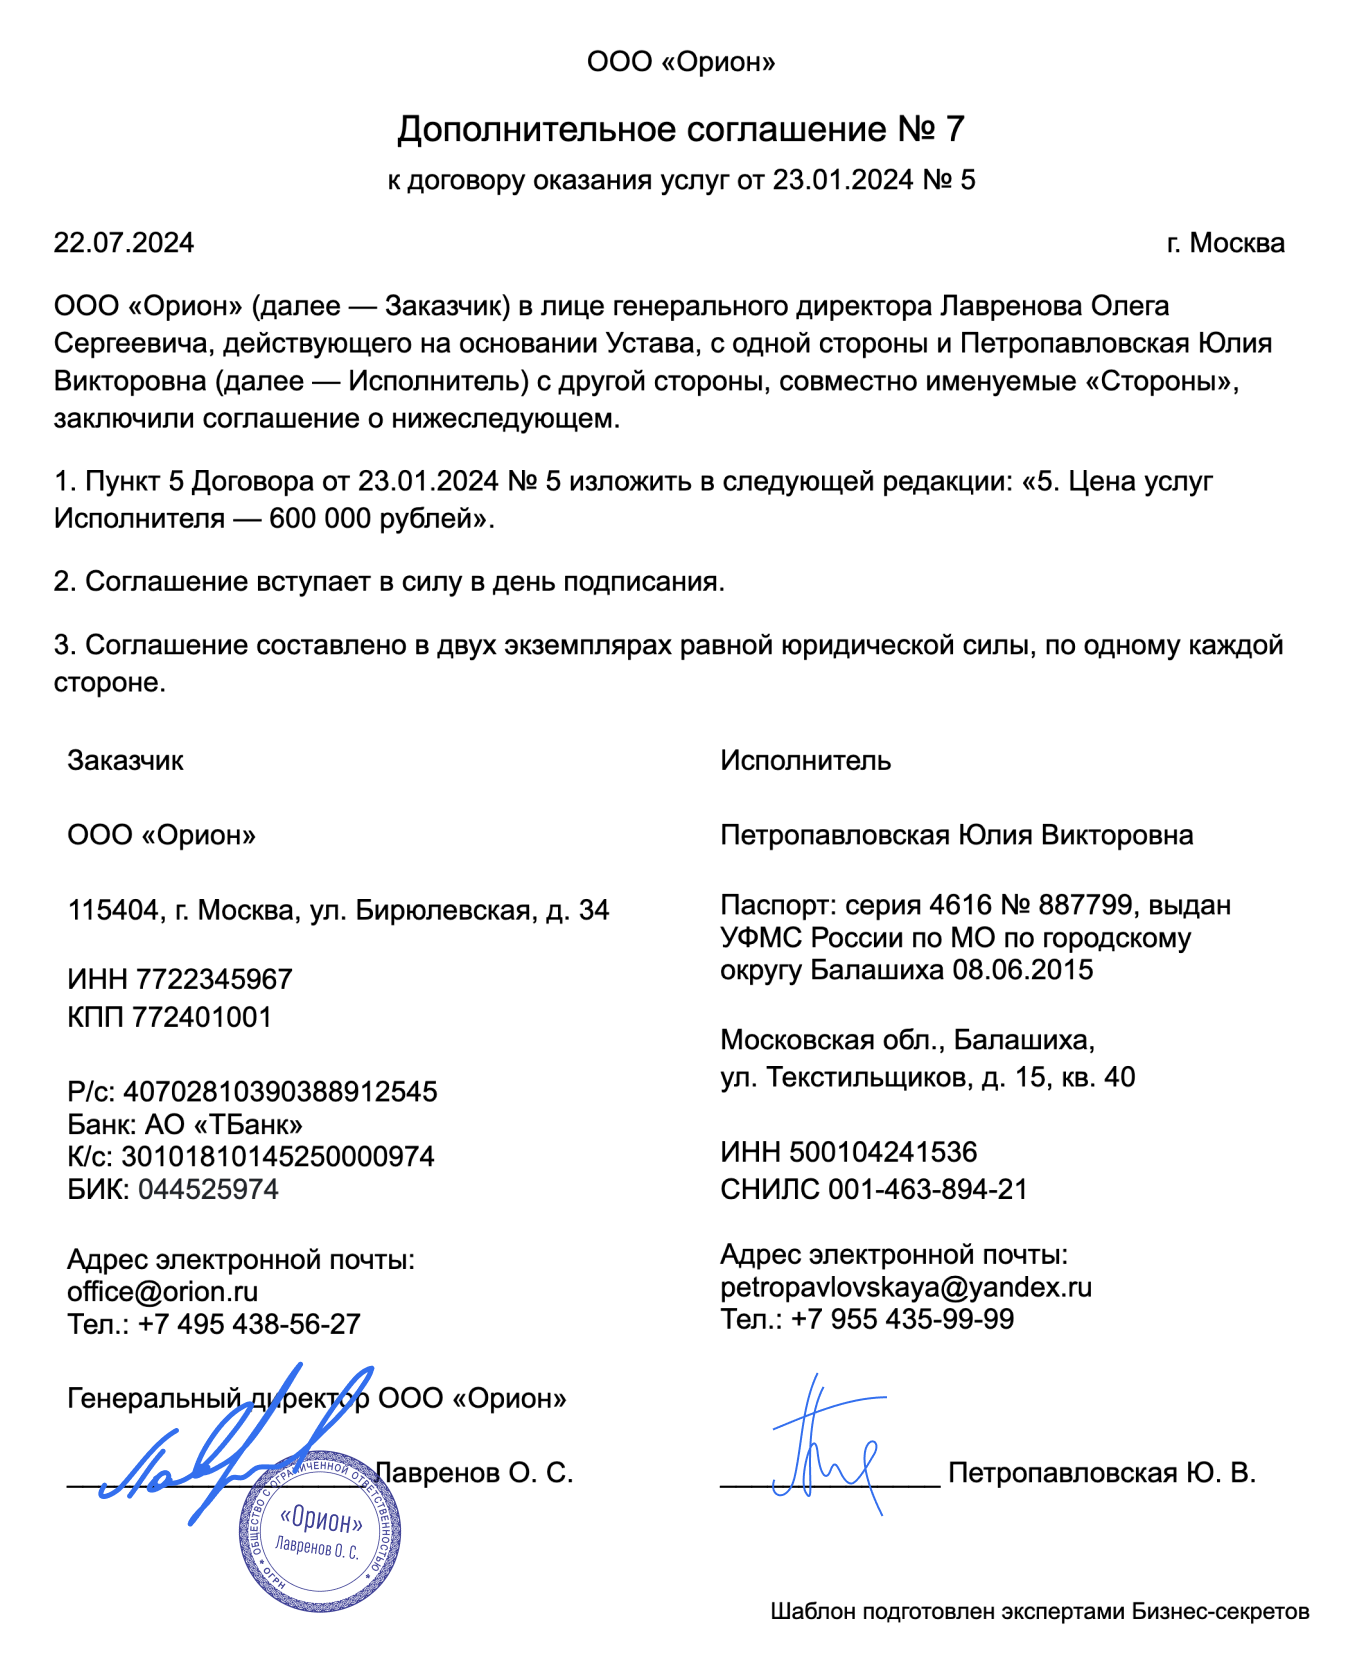

In [ ]:
from PIL import Image

image_path = '../data/orion_agreement.png'
image = Image.open(image_path).convert("RGB")
image

In [5]:
orig_w, orig_h = image.size
spotting_upscale_threshold = 1500
orig_w, orig_h 

(934, 1020)

In [7]:
for p in model.parameters():
    print(p.device)
    break

cuda:0


In [ ]:
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image },
            # {"type": "text", "text": "OCR"},
            {"type": "text", "text": "Извлеки сущности директор или исполнитель или заказчик и исполнитель и выдай в формате json"}
        ]
    }
]

inputs = processor.apply_chat_template(
    messages,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt",
    # images_kwargs={}
).to(model.device)

with torch.inference_mode():
    outputs = model.generate(**inputs, max_new_tokens=512)
result = processor.decode(outputs[0][inputs["input_ids"].shape[-1]:-1])
result

'000 «Орион»\nДополнительное соглашение № 7\nк договору оказания услуг от 23.01.2024 № 5\nг. Москва\n22.07.2024\n000 «Орион» (далее — Заказчик) в лице генерального директора Лавренова Олега Сергеевича, действующего на основании Устава, с одной стороны и Петропавловская Юлия Викторовна (далее — Исполнитель) с другой стороны, совместно именуемые «Стороны», заключили соглашение о нижеследующем.\n1. Пункт 5 Договора от 23.01.2024 № 5 изложить в следующей редакции: «5. Цена услуг Исполнителя — 600 000 рублей».\n2. Соглашение вступает в силу в день подписания.\n3. Соглашение составлено в двух экземплярах равной юридической силы, по одному каждой стороне.\nЗаказчик\n000 «Орион»\n115404, г. Москва, ул. Бирюлевская, д. 34\nИНН 7722345967\nКПП 772401001\nР/с: 40702810390388912545\nБанк: АО «ТБанк»\nК/с: 30101810145250000974\nБИК: 044525974\nАдрес электронной почты: office@orion.ru\nТел.: +7 495 438-56-27\nГенеральный директор ООО'

In [12]:
print(result)

000 «Орион»
Дополнительное соглашение № 7
к договору оказания услуг от 23.01.2024 № 5
г. Москва
22.07.2024
000 «Орион» (далее — Заказчик) в лице генерального директора Лавренова Олега Сергеевича, действующего на основании Устава, с одной стороны и Петропавловская Юлия Викторовна (далее — Исполнитель) с другой стороны, совместно именуемые «Стороны», заключили соглашение о нижеследующем.
1. Пункт 5 Договора от 23.01.2024 № 5 изложить в следующей редакции: «5. Цена услуг Исполнителя — 600 000 рублей».
2. Соглашение вступает в силу в день подписания.
3. Соглашение составлено в двух экземплярах равной юридической силы, по одному каждой стороне.
Заказчик
000 «Орион»
115404, г. Москва, ул. Бирюлевская, д. 34
ИНН 7722345967
КПП 772401001
Р/с: 40702810390388912545
Банк: АО «ТБанк»
К/с: 30101810145250000974
БИК: 044525974
Адрес электронной почты: office@orion.ru
Тел.: +7 495 438-56-27
Генеральный директор ООО


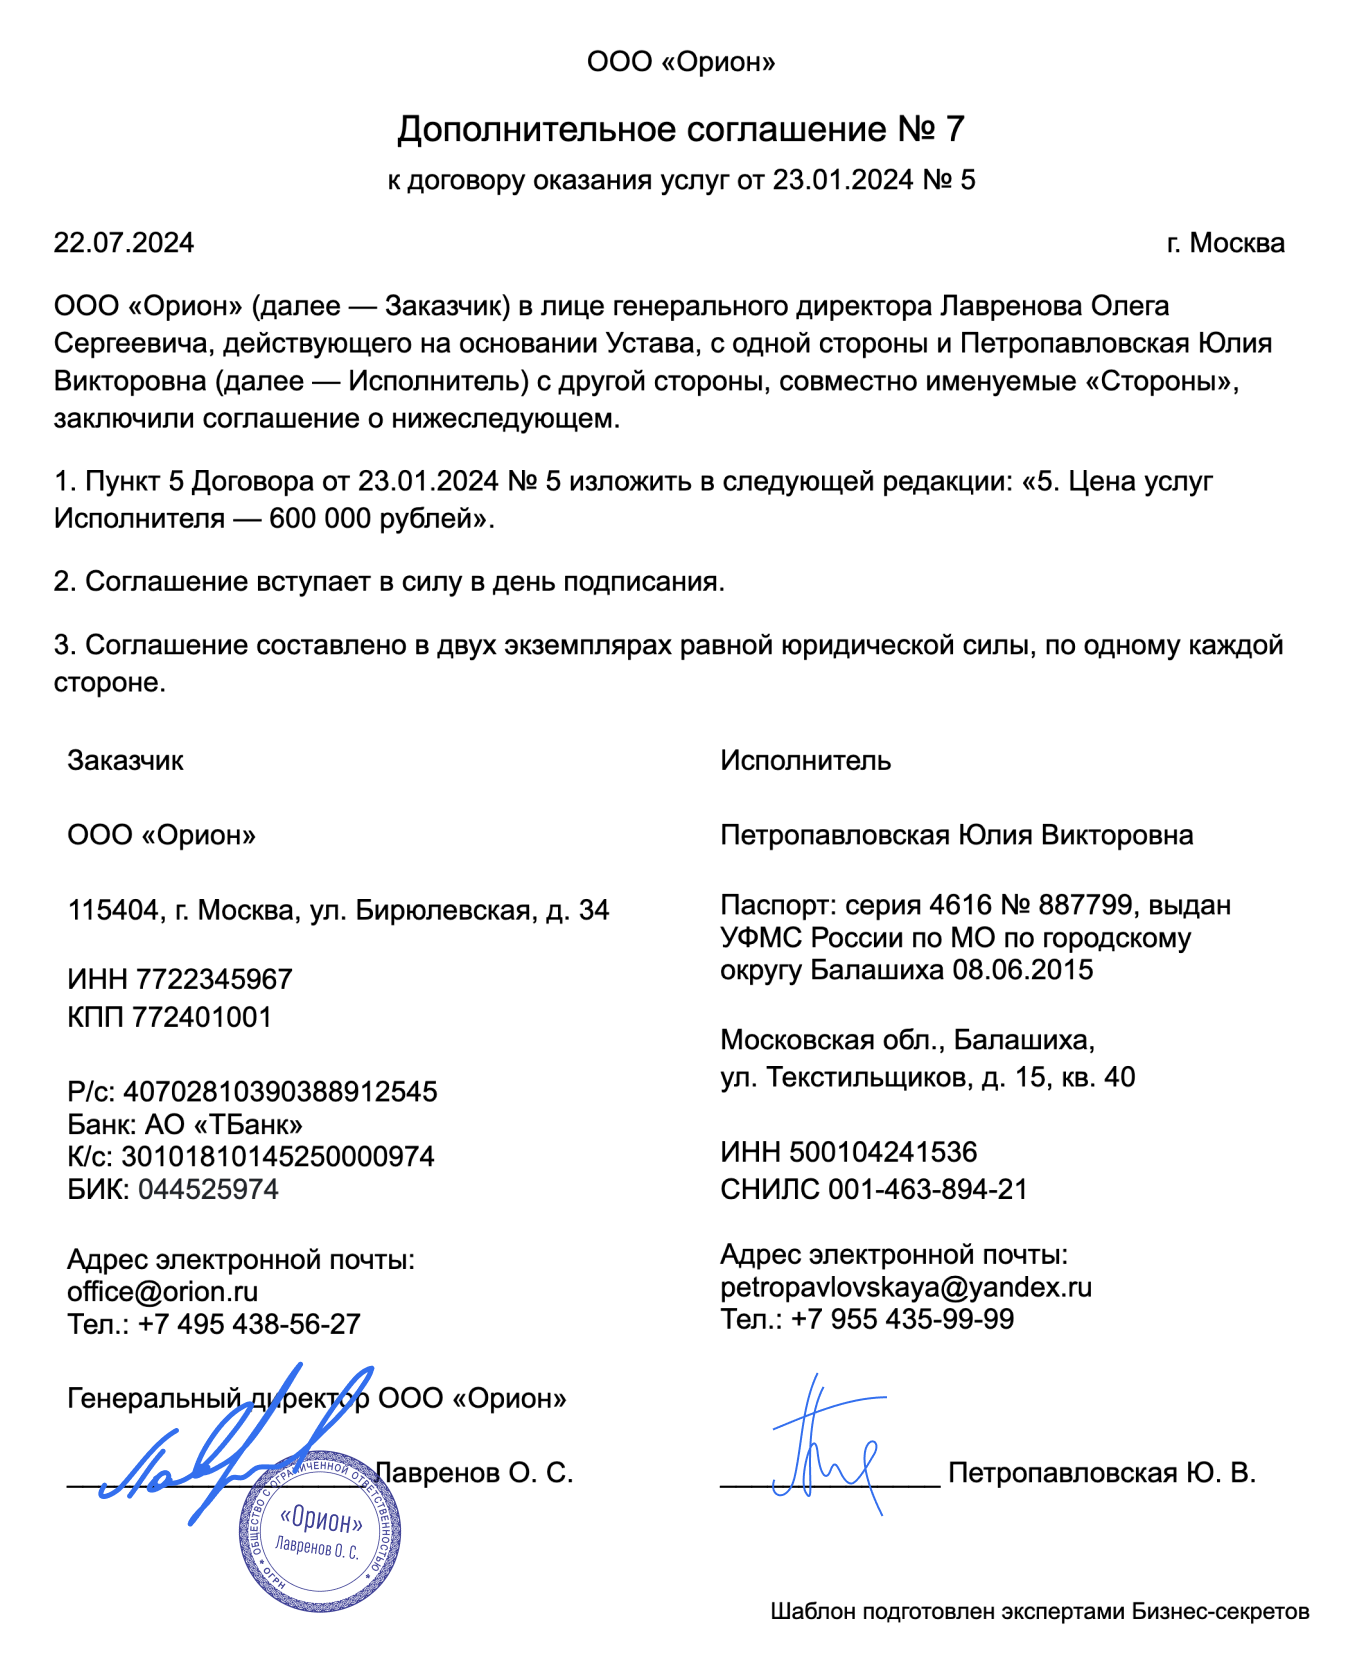

In [3]:
from PIL import Image

image_path = '../data/orion_agreement.png'
image = Image.open(image_path).convert("RGB")
image

In [4]:
from paddleocr import PaddleOCR

RuntimeError: PDX has already been initialized. Reinitialization is not supported.

In [6]:
import torch

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE

ImportError: /home/ilgiz/invoice_ai/.venv/lib/python3.12/site-packages/torch/lib/libtorch_cuda.so: undefined symbol: ncclCommResume

In [3]:
ocr = PaddleOCR(
    lang='ru',
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False,
    device='gpu',
    text_detection_model_name="PP-OCRv5_mobile_det",
    text_recognition_model_name="PP-OCRv5_mobile_rec"
)

/tmp/ipykernel_609218/3661858409.py:1: UserWarning: `lang` and `ocr_version` will be ignored when model names or model directories are not `None`.
  ocr = PaddleOCR(
Creating model: ('PP-OCRv5_mobile_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/ilgiz/.paddlex/official_models/PP-OCRv5_mobile_det`.


AttributeError: 'paddle.base.libpaddle.AnalysisConfig' object has no attribute 'set_optimization_level'

# PaddleOCR engine 

## Downloading models

In [ ]:
from paddleocr import PaddleOCR

ocr = PaddleOCR(
    lang='ru',
    
    # det config
    # text_detection_model_dir=working_dir_path.parent / 'models' / 'det',
    text_detection_model_name="PP-OCRv5_server_det",
    text_det_box_thresh=0.5,
    text_det_thresh=0.3,
    text_det_unclip_ratio=1.6,  # расширение bbox (важно для плотного текста!)
    
    # rec config
    # text_recognition_model_dir=working_dir_path.parent / 'models' / 'rec',
    text_recognition_model_name="PP-OCRv5_server_rec",
    text_recognition_batch_size=6,
    
    # Классификатор поворота строк
    use_doc_orientation_classify=True,
    device='gpu'
)
ocr

/tmp/ipykernel_521584/485452302.py:3: UserWarning: `lang` and `ocr_version` will be ignored when model names or model directories are not `None`.
  ocr = PaddleOCR(
Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Using official model (PP-LCNet_x1_0_doc_ori), the model files will be automatically downloaded and saved in `/home/ilgiz/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Fetching 6 files: 100%|██████████| 6/6 [00:02<00:00,  2.17it/s]
Creating model: ('UVDoc', None, None)
Using official model (UVDoc), the model files will be automatically downloaded and saved in `/home/ilgiz/.paddlex/official_models/UVDoc`.
Fetching 6 files: 100%|██████████| 6/6 [00:04<00:00,  1.38it/s]
Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Using official model (PP-LCNet_x1_0_textline_ori), the model files will be automatically downloaded and saved in `/home/ilgiz/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Fetching 6 files: 100%|██████████| 6/6 [00:01<00:00,  4.37it/s]
Crea

In [40]:
from paddleocr import PaddleOCR

ocr = PaddleOCR(
    lang='ru',
    
    # det config
    # text_detection_model_dir=working_dir_path.parent / 'models' / 'det',
    text_detection_model_name="PP-OCRv5_server_det",
    text_det_box_thresh=0.5,
    text_det_thresh=0.3,
    text_det_unclip_ratio=1.6,  # расширение bbox (важно для плотного текста!)
    
    # rec config
    # text_recognition_model_dir=working_dir_path.parent / 'models' / 'rec',
    text_recognition_model_name="eslav_PP-OCRv5_mobile_rec",
    text_recognition_batch_size=6,
    
    # Классификатор поворота строк
    use_doc_orientation_classify=True,
    device='gpu'
)
ocr

/tmp/ipykernel_521584/1416111432.py:3: UserWarning: `lang` and `ocr_version` will be ignored when model names or model directories are not `None`.
  ocr = PaddleOCR(
Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/ilgiz/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/ilgiz/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/ilgiz/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/ilgiz/.paddlex/official_models/PP-OCRv5_server_de

## Loading PaddleOCR model from local dirs
Copied via terminal

```bash
cp -r /home/ilgiz/.paddlex/official_models/PP-OCRv5_server_det/* models/det/
cp -r /home/ilgiz/.paddlex/official_models/PP-OCRv5_server_rec/* models/rec/
cp -r /home/ilgiz/.paddlex/official_models/eslav_PP-OCRv5_mobile_rec/* models/rec/
```

In [1]:
from pathlib import Path

working_dir_path = Path('.').resolve()
print(working_dir_path)
print((working_dir_path.parent / 'models' / 'det').exists())

/home/ilgiz/invoice_ai/notebooks
True


In [2]:
from paddleocr import PaddleOCR

ocr = PaddleOCR(
    # det config
    text_detection_model_dir=working_dir_path.parent / 'models' / 'det',
    text_detection_model_name="PP-OCRv5_server_det",
    text_det_box_thresh=0.5,
    text_det_thresh=0.3,
    text_det_unclip_ratio=1.6,  # расширение bbox (важно для плотного текста!)
    
    # rec config
    text_recognition_model_name="eslav_PP-OCRv5_mobile_rec",
    text_recognition_model_dir=working_dir_path.parent / 'models' / 'rec',
    # text_recognition_model_name="PP-OCRv5_server_rec",
    text_recognition_batch_size=6,
    
    # Классификатор поворота строк
    doc_orientation_classify_model_dir=working_dir_path.parent / 'models' / 'doc_orientation',
    use_doc_orientation_classify=True,
        
    use_doc_unwarping=False,
    use_textline_orientation=False,
    device='gpu'
)
ocr

Creating model: ('PP-LCNet_x1_0_doc_ori', PosixPath('/home/ilgiz/invoice_ai/models/doc_orientation'), None)
/home/ilgiz/invoice_ai/.venv/lib/python3.11/site-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-OCRv5_server_det', PosixPath('/home/ilgiz/invoice_ai/models/det'), None)
Creating model: ('eslav_PP-OCRv5_mobile_rec', PosixPath('/home/ilgiz/invoice_ai/models/rec'), None)


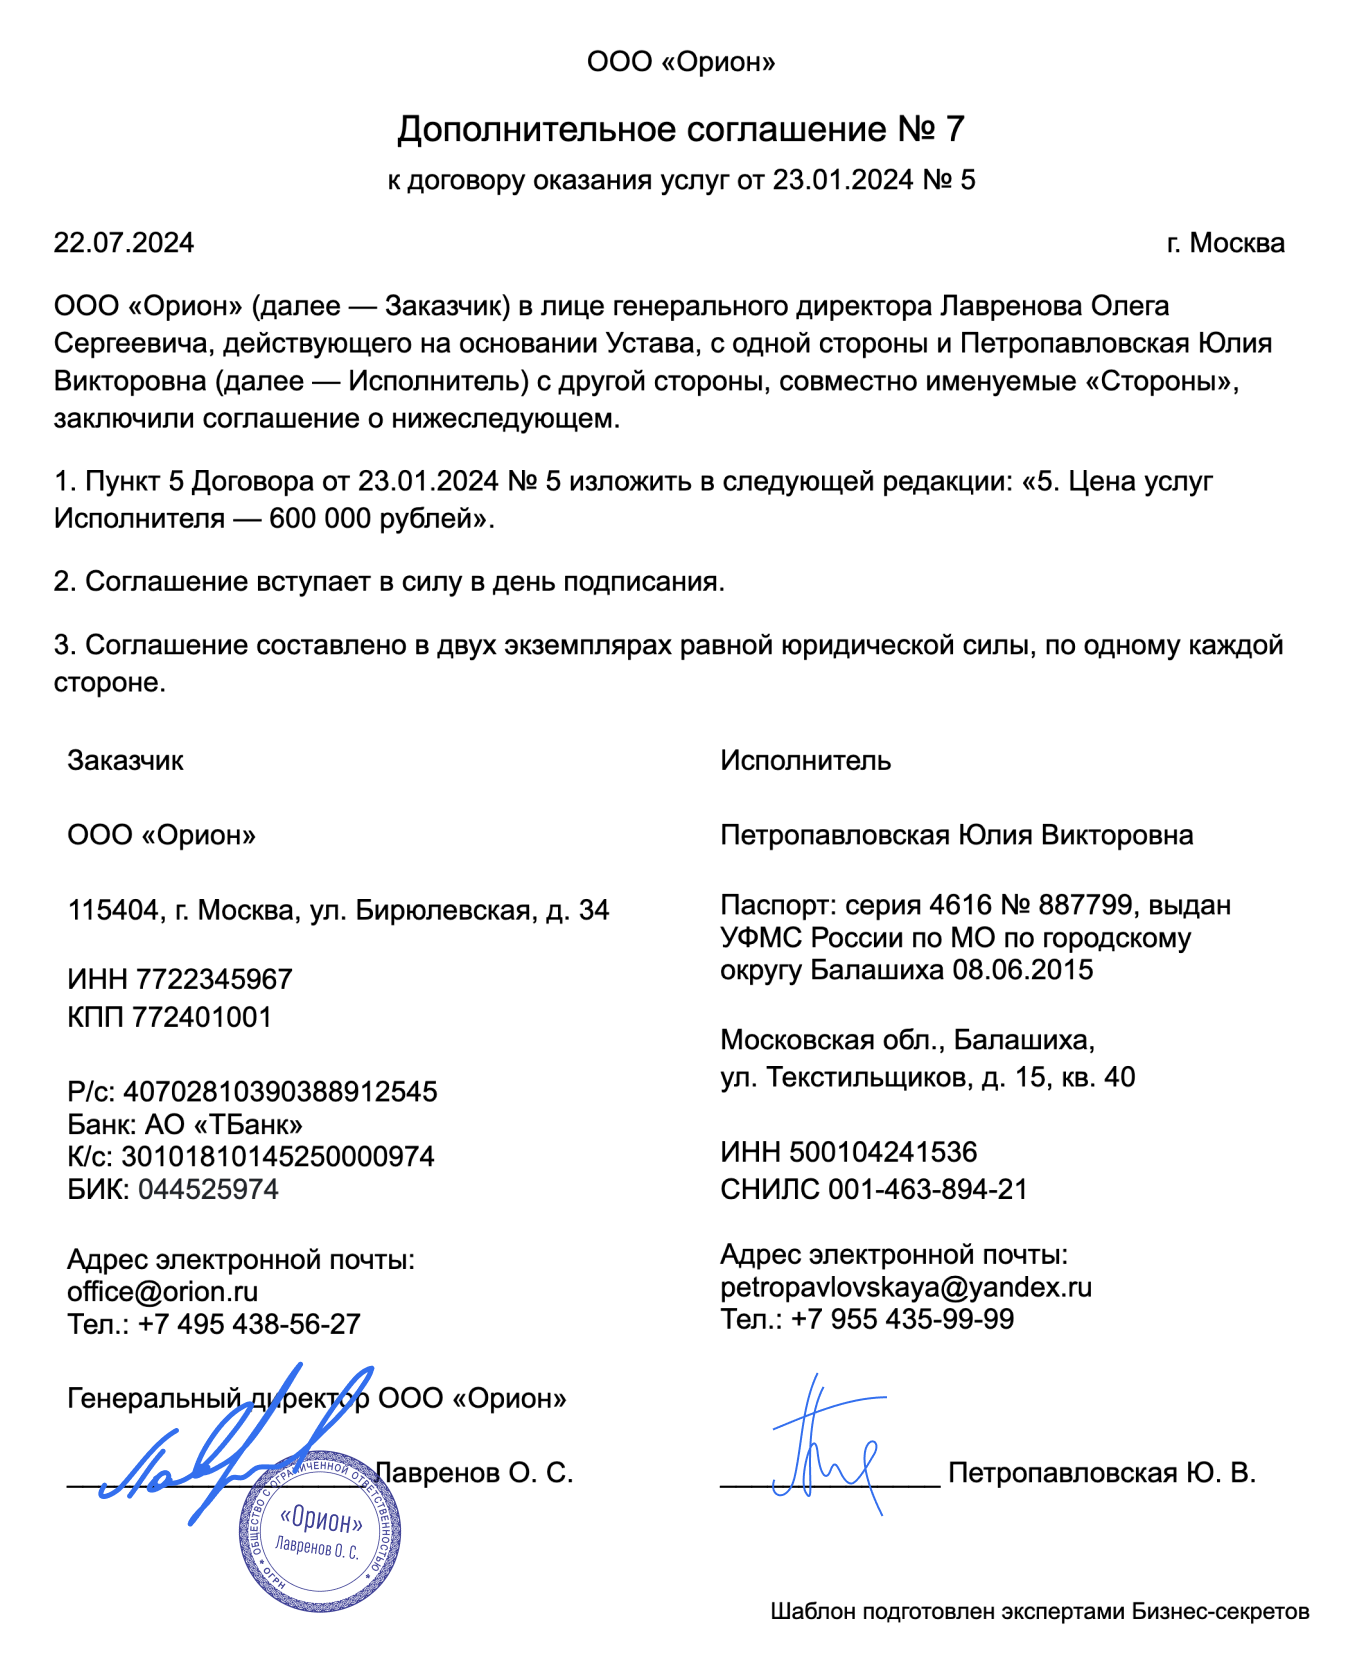

In [3]:
from PIL import Image

image_path = Path(working_dir_path.parent) / 'data' / 'orion_agreement.png'
Image.open(image_path).convert('RGB')

In [4]:
result = ocr.predict(str(image_path))
result

[{'input_path': '/home/ilgiz/invoice_ai/data/orion_agreement.png',
  'page_index': None,
  'doc_preprocessor_res': {'input_path': None,
   'page_index': None,
   'input_img': array([[[255, ..., 255],
           ...,
           [255, ..., 255]],
   
          ...,
   
          [[255, ..., 255],
           ...,
           [255, ..., 255]]], shape=(1679, 1360, 3), dtype=uint8),
   'model_settings': {'use_doc_orientation_classify': True,
    'use_doc_unwarping': False},
   'angle': 0,
   'rot_img': array([[[255, ..., 255],
           ...,
           [255, ..., 255]],
   
          ...,
   
          [[255, ..., 255],
           ...,
           [255, ..., 255]]], shape=(1679, 1360, 3), dtype=uint8),
   'output_img': array([[[255, ..., 255],
           ...,
           [255, ..., 255]],
   
          ...,
   
          [[255, ..., 255],
           ...,
           [255, ..., 255]]], shape=(1679, 1360, 3), dtype=uint8)},
  'dt_polys': [array([[581,  40],
          ...,
          [581,  78]], s

In [5]:
result[0].keys()

dict_keys(['input_path', 'page_index', 'doc_preprocessor_res', 'dt_polys', 'model_settings', 'text_det_params', 'text_type', 'text_rec_score_thresh', 'return_word_box', 'rec_texts', 'rec_scores', 'rec_polys', 'vis_fonts', 'textline_orientation_angles', 'rec_boxes'])

In [6]:
result[0].get('rec_texts', None)

['000Орион»',
 'Дополнительное соглашение № 7',
 'к договору оказания услуг от 23.01.2024 № 5',
 '22.07.2024',
 'г. Москва',
 'ООО«Орион» (далее — Заказчик) в лице генерального директора Лавренова Олега',
 'Сергеевича, действующего на основании Устава, с одной стороны и Петропавловская Юлия',
 'Викторовна (далее — Исполнитель) с другой стороны, совместно именуемые «Стороны»,',
 'заключили соглашение о нижеследующем.',
 '1. Пункт 5 Договора от 23.01.2024 № 5 изложить в следующей редакции: «5. Цена услуг',
 'Исполнителя — 600 000 рублей».',
 '2. Соглашение вступает в силу в день подписания.',
 '3.Соглашение составлено в двух экземплярах равной юридической силы, по одному каждой',
 'стороне.',
 'Заказчик',
 'Исполнитель',
 '000Орион»',
 'Петропавловская Юлия Викторовна',
 '115404, г. МоскВа, ул. Бирюлевская, д. 34',
 'Паспорт: серия 4616 № 887799, выдан',
 'УФМС России по МО по городскому',
 'ИHH 7722345967',
 'округу Балашиха 08.06.2015',
 'КПП 772401001',
 'Московская обл., Балашиха,',


In [7]:
ocr_text = ' '.join(result[0].get('rec_texts', None))
ocr_text

'000Орион» Дополнительное соглашение № 7 к договору оказания услуг от 23.01.2024 № 5 22.07.2024 г. Москва ООО«Орион» (далее — Заказчик) в лице генерального директора Лавренова Олега Сергеевича, действующего на основании Устава, с одной стороны и Петропавловская Юлия Викторовна (далее — Исполнитель) с другой стороны, совместно именуемые «Стороны», заключили соглашение о нижеследующем. 1. Пункт 5 Договора от 23.01.2024 № 5 изложить в следующей редакции: «5. Цена услуг Исполнителя — 600 000 рублей». 2. Соглашение вступает в силу в день подписания. 3.Соглашение составлено в двух экземплярах равной юридической силы, по одному каждой стороне. Заказчик Исполнитель 000Орион» Петропавловская Юлия Викторовна 115404, г. МоскВа, ул. Бирюлевская, д. 34 Паспорт: серия 4616 № 887799, выдан УФМС России по МО по городскому ИHH 7722345967 округу Балашиха 08.06.2015 КПП 772401001 Московская обл., Балашиха, ул. Текстильщиков, д. 15, кв. 40 P/c: 40702810390388912545 Банк: АО «ТБанк» K/c: 301018101452500009

In [8]:
from dotenv import load_dotenv
from huggingface_hub import login, whoami
import os

load_dotenv()

login(os.getenv("HF_TOKEN")) 
whoami()

{'type': 'user',
 'id': '69dccea6cc84b21017cd8b11',
 'name': 'Swanger',
 'fullname': 'Ilgiz Magadiev',
 'email': 'swanger789@gmail.com',
 'emailVerified': True,
 'canPay': False,
 'billingMode': 'prepaid',
 'periodEnd': 1782864000,
 'isPro': False,
 'avatarUrl': 'https://cdn-avatars.huggingface.co/v1/production/uploads/noauth/jcURzxKNPxN4WriN5lft1.jpeg',
 'orgs': [],
 'auth': {'type': 'access_token',
  'accessToken': {'displayName': 'colab_hf_learn',
   'role': 'read',
   'createdAt': '2026-04-13T11:18:25.462Z'}}}

## Loading Qwen model

In [9]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch
# model_id = "Qwen/Qwen2.5-1.5B-Instruct"
model_id = "Qwen/Qwen2.5-3B-Instruct"

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    dtype=torch.float16,
    device_map="cuda"
)
tokenizer = AutoTokenizer.from_pretrained(model_id)


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

## Generation

In [10]:
messages = [
    {
    "role": "system",
    "content": """Ты — система извлечения данных из договоров.

        ПРАВИЛА (строго соблюдай):
        1. Извлекай ТОЛЬКО ФИО физического лица в формате: Фамилия Имя Отчество
        2. Названия компаний (ООО, ИП, АО) — НЕ извлекать, они не являются ответом
        3. Если заказчик — компания, найди ФИО после фразы 'в лице'
        4. Если сторона не найдена — верни null
        5. Ответ ТОЛЬКО в JSON, никаких пояснений

        ФОРМАТ ОТВЕТА:
        {"заказчик": "Фамилия Имя Отчество", "исполнитель": "Фамилия Имя Отчество"}

        ПРИМЕРЫ ПРАВИЛЬНЫХ ОТВЕТОВ:
        {"заказчик": "Лавренов Олег Сергеевич", "исполнитель": "Петропавловская Юлия Викторовна"}
        {"заказчик": "Смирнов Дмитрий Александрович", "исполнитель": null}"""
    },
    {
        "role": "user",
        "content": """Извлеки ФИО заказчика и исполнителя из текста договора:

        ООО«Блундинг» (далее — Заказчик) в лице генерального директора Кучкова Игоря Дмитривиевича,
        действующего на основании Устава, с одной стороны и Петропавловская
        Юлия Викторовна (далее — Исполнитель) с другой стороны."""
    },
    {
        "role": "assistant",
        "content": '{"заказчик": "Кучков Игорь Дмитриевич", "исполнитель": "Петропавловская Юлия Викторовна"}'
    },

    # Few-shot пример 1 — стандартный договор с юр. лицом
    {
        "role": "user",
        "content": """Извлеки ФИО заказчика и исполнителя из текста договора:

        ООО «Альфа» в лице генерального директора Смирнова Дмитрия Александровича,
        действующего на основании Устава, именуемое в дальнейшем «Заказчик»,
        и Королёва Наталья Викторовна, именуемая в дальнейшем «Исполнитель»,
        заключили настоящий договор."""
    },
    {
        "role": "assistant",
        "content": '{"заказчик": "Смирнов Дмитрий Александрович", "исполнитель": "Королёва Наталья Викторовна"}'
    },

    # Few-shot пример 2 — оба физ. лица
    {
        "role": "user",
        "content": """Извлеки ФИО заказчика и исполнителя из текста договора:

        Гражданин Захаров Павел Олегович, именуемый в дальнейшем «Заказчик»,
        и гражданка Михайлова Ирина Сергеевна, именуемая в дальнейшем «Исполнитель»,
        составили настоящее соглашение."""
    },
    {
        "role": "assistant",
        "content": '{"заказчик": "Захаров Павел Олегович", "исполнитель": "Михайлова Ирина Сергеевна"}'
    },

    # Few-shot пример 3 — данные есть только частично
    {
        "role": "user",
        "content": """Извлеки ФИО заказчика и исполнителя из текста договора:

        ИП Волков Андрей Николаевич, именуемый в дальнейшем «Заказчик»,
        заключил настоящий договор на оказание услуг."""
    },
    {
        "role": "assistant",
        "content": '{"заказчик": "Волков Андрей Николаевич", "исполнитель": null}'
    },

    # Реальный запрос
    {
        "role": "user",
        "content": f"Извлеки ФИО заказчика и исполнителя из текста договора:\n\n{ocr_text}"
    }
]

In [12]:
messages[0]["content"]

'Ты — система извлечения данных из договоров.\n\n        ПРАВИЛА (строго соблюдай):\n        1. Извлекай ТОЛЬКО ФИО физического лица в формате: Фамилия Имя Отчество\n        2. Названия компаний (ООО, ИП, АО) — НЕ извлекать, они не являются ответом\n        3. Если заказчик — компания, найди ФИО после фразы \'в лице\'\n        4. Если сторона не найдена — верни null\n        5. Ответ ТОЛЬКО в JSON, никаких пояснений\n\n        ФОРМАТ ОТВЕТА:\n        {"заказчик": "Фамилия Имя Отчество", "исполнитель": "Фамилия Имя Отчество"}\n\n        ПРИМЕРЫ ПРАВИЛЬНЫХ ОТВЕТОВ:\n        {"заказчик": "Лавренов Олег Сергеевич", "исполнитель": "Петропавловская Юлия Викторовна"}\n        {"заказчик": "Смирнов Дмитрий Александрович", "исполнитель": null}'

In [11]:
text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True  # добавляет <|assistant|> в конец
)

In [12]:
inputs = tokenizer(text, return_tensors='pt').to(model.device)
inputs

{'input_ids': tensor([[151644,   8948,    198,  ..., 151644,  77091,    198]],
       device='cuda:0'), 'attention_mask': tensor([[1, 1, 1,  ..., 1, 1, 1]], device='cuda:0')}

In [13]:
with torch.inference_mode():
    outputs = model.generate(
        **inputs,
        max_new_tokens=50,
        temperature=0.1,  # низкая = детерминированный ответ (для извлечения данных)
        do_sample=True,  # нужен если temperature != 1.0
        repetition_penalty=1.1  # избегает повторений
    )

In [14]:
input_len = inputs["input_ids"].shape[1]
response = tokenizer.decode(
    outputs[0][input_len:],
    skip_special_tokens=True
)

print(response)

{"заказчик": "Лавренов Олег Сергеевич", "исполнитель": "Петропавловская Юлия Викторовна"}
